# Titled Tuesday — Win Probability Model (Plackett-Luce)

Three-component decomposition for the **July 8, 2026** tournament.

| Component | Method | Decay |
|-----------|--------|-------|
| **E[field size]** | Recency-weighted avg of past headcounts | 0.85 / event |
| **P(enters)** | Recency-weighted attendance fraction | 0.85 / event |
| **P(wins \| enters)** | Plackett-Luce latent strength (rank-based MLE) | 0.99 / event |

**Plackett-Luce model:** each player $i$ has a latent strength $w_i > 0$.
Given the full rank ordering of a tournament, the probability of that ordering is
$$P(\pi) = \prod_{k=1}^{n} \frac{w_{\pi_k}}{\sum_{j \geq k} w_{\pi_j}}$$
The probability player $i$ wins = $w_i / \sum_j w_j$.
Strengths are estimated by the Hunter MM algorithm applied to all historical rank
orderings, weighted by recency. This uses **rank only** — score and round count
are irrelevant to the model.

**Win probability:**
$$P(i\text{ top 3}) = p_i \cdot \frac{w_i}{\sum_j p_j w_j}$$

In [2]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

## 1  Load data and build tournament index

In [3]:
standings   = pd.read_csv('data/titled_tuesday_standings.csv',   parse_dates=['date'])
tournaments = pd.read_csv('data/titled_tuesday_tournaments.csv', parse_dates=['date'])

DATA_CUTOFF         = '2022-02-01'
SKILL_DECAY         = 0.975   # per event — mild; rank-based skill is stable
PARTICIPATION_DECAY = 0.85   # per event — high recency bias
SIZE_DECAY          = 0.85   # per event — high recency bias

df = standings[standings['date'] >= DATA_CUTOFF].copy()

# Deduplicate: if a player appears twice in one event (data artefact),
# keep only their best (lowest) rank.
df = (
    df.sort_values('rank')
    .drop_duplicates(subset=['tournament_slug', 'username'], keep='first')
)

# Ordered unique tournament events (early + late are separate slugs).
tourn_df = (
    df[['date', 'session', 'tournament_slug']]
    .drop_duplicates('tournament_slug')
    .sort_values(['date', 'session'])
    .reset_index(drop=True)
)
N          = len(tourn_df)
tourn_df['t_idx'] = range(N)
slug_to_idx = dict(zip(tourn_df['tournament_slug'], tourn_df['t_idx']))
slug_order  = tourn_df['tournament_slug'].tolist()
tick_dates  = tourn_df['date'].tolist()

df['t_idx'] = df['tournament_slug'].map(slug_to_idx)
df['rw_part'] = PARTICIPATION_DECAY ** (N - 1 - df['t_idx'])

# Rank percentile: 1.0 = winner, 0.0 = last place
n_in_tourn     = df.groupby('tournament_slug')['username'].transform('count')
df['rank_pct'] = 1.0 - (df['rank'].astype(float) - 1) / (n_in_tourn - 1)

print(f'Events      : {N}  (early+late counted separately)')
print(f'Unique players: {df["username"].nunique():,}')
print(f'Date range  : {tourn_df["date"].iloc[0].date()} to {tourn_df["date"].iloc[-1].date()}')

Events      : 417  (early+late counted separately)
Unique players: 8,809
Date range  : 2022-02-01 to 2026-06-30


## 2  Component 1 — Expected field size

In [4]:
event_sizes = (
    df.groupby('tournament_slug')
    .agg(n_players=('username', 'count'), t_idx=('t_idx', 'first'))
    .reset_index()
)
event_sizes['rw'] = SIZE_DECAY ** (N - 1 - event_sizes['t_idx'])
expected_size = (
    (event_sizes['n_players'] * event_sizes['rw']).sum()
    / event_sizes['rw'].sum()
)
print(f'Expected field size (July 8, 2026): {expected_size:.0f} players')

Expected field size (July 8, 2026): 432 players


## 3  Component 2 — P(player enters)

$$p_i = \frac{\sum_{t:\,i \in t} \delta^{N-1-t}}{\sum_{t=0}^{N-1} \delta^{N-1-t}}, \quad \delta = 0.85$$

In [5]:
Z_part = sum(PARTICIPATION_DECAY**k for k in range(N))
p_participate = (
    df.groupby('username')['rw_part'].sum() / Z_part
).rename('p_participate')
print(f'Z_part = {Z_part:.2f}')
print(f'Players with p >= 0.50: {(p_participate >= 0.50).sum()}')
print(f'Players with p >= 0.10: {(p_participate >= 0.10).sum()}')

Z_part = 6.67
Players with p >= 0.50: 250
Players with p >= 0.10: 1140


## 4  Component 3 — Plackett-Luce latent strength

The Hunter (2004) MM algorithm maximises the recency-weighted Plackett-Luce
log-likelihood. Each iteration updates every player's strength as:

$$w_i \leftarrow
\frac{\displaystyle\sum_{t:\,i \in t} \rho_t}
{\displaystyle\sum_{t:\,i \in t} \rho_t
\sum_{k=1}^{\text{rank}_t(i)}
\frac{1}{\sum_{j:\,\text{rank}_t(j) \geq k} w_j}},
\quad \rho_t = 0.99^{N-1-t}$$

**Minimum-appearances filter:** players with fewer than `MIN_APPEARANCES`
tournament entries are excluded from the MLE and assigned the global mean
strength ($w = 1$). Without this filter, a player who appeared once and
finished 2nd in a 400-player field gets an astronomically high MLE estimate
(it 'saw' them beat 399 players with no data pulling the estimate back down).
This distorts comparison sets for *everyone else*, systematically compressing
estimated skill differences among the regulars and making the eventual
win-probability estimates unreliable.

In [6]:
# ═══════════════════ Truncated (top-N) Plackett-Luce ═════════════════════
# Likelihood per event:   prod_{j=1..k}  w_(j) / sum_{i>=j} w_(i)
# where k = number of modelled stages (finishes with rank <= TOP_N).
#   * Positions 1..k are sequential "choices" and earn numerator credit.
#   * Positions > k form an UNORDERED tail: those players still appear in
#     the first k denominators (they were available to be picked), but the
#     order in which they limped home is ignored — a tilted round 8 no
#     longer drags a star's strength down.

TOP_N           = 10   # only the first TOP_N finishing positions are modelled
MIN_APPEARANCES = 5     # players below this threshold are excluded from the MLE
PRIOR_A         = 0.1   # Gamma-prior pseudo-counts:  w = (num+A)/(den+B).
PRIOR_B         = 0.1   # Prior mean A/B = 1. Without it, anyone with zero
                        # top-N finishes has MLE exactly 0 (degenerate).

# ── Filter to well-observed players ──────────────────────────────────────
app_counts = df.groupby('username')['tournament_slug'].nunique()
pl_players = set(app_counts[app_counts >= MIN_APPEARANCES].index)
df_pl = df[df['username'].isin(pl_players)].copy()

print(f'Players with >= {MIN_APPEARANCES} appearances: {len(pl_players):,}')
print(f'Rows used for MLE : {len(df_pl):,}  ({len(df_pl)/len(df)*100:.1f}% of all rows)')

# ── Pre-compute per-tournament data structures ───────────────────────────
all_usernames = df_pl['username'].unique().tolist()
uidx          = {u: i for i, u in enumerate(all_usernames)}
n_pl          = len(all_usernames)

df_sorted   = df_pl.sort_values(['tournament_slug', 'rank'])
slug_groups = df_sorted.groupby('tournament_slug')

# k_eff = number of modelled choice stages = qualifying players whose ACTUAL
# tournament rank (not rank within the modelled subset) is <= TOP_N, capped
# at n-1 because the final stage of a complete ranking is uninformative.
tourn_idx_arr = []   # player indices, sorted by finishing rank
tourn_k_arr   = []   # number of truncated stages for this event
tourn_rw_arr  = []   # time-decay weight

head_rows = tail_rows = 0
for slug in slug_order:
    if slug not in slug_groups.groups:
        continue
    grp = slug_groups.get_group(slug)
    if len(grp) < 2:
        continue
    k_eff = min(int((grp['rank'] <= TOP_N).sum()), len(grp) - 1)
    if k_eff == 0:
        continue      # no modelled player finished in the top N: no signal
    idx = np.fromiter((uidx[u] for u in grp['username']),
                      dtype=np.int32, count=len(grp))
    t = grp['t_idx'].iloc[0]
    tourn_idx_arr.append(idx)
    tourn_k_arr.append(k_eff)
    tourn_rw_arr.append(SKILL_DECAY ** (N - 1 - t))
    head_rows += k_eff
    tail_rows += len(grp) - k_eff

print(f'Events with >= 1 modelled top-{TOP_N} finisher: {len(tourn_idx_arr)}')
print(f'Ranked (head) rows: {head_rows:,}   denominator-only (tail) rows: {tail_rows:,}')

# Players with at least one modelled top-N finish anchor the normalisation
# (mean strength = 1 within this group). A global mean would be dominated by
# the thousands of never-top-N players whose strengths sit near the prior.
has_topn = np.zeros(n_pl, dtype=bool)
for idx, k in zip(tourn_idx_arr, tourn_k_arr):
    has_topn[idx[:k]] = True
print(f'Players with >= 1 top-{TOP_N} finish: {has_topn.sum():,} of {n_pl:,}')

# ── MM iterations (Hunter 2004, truncated) ───────────────────────────────
N_ITER = 400
w      = np.ones(n_pl, dtype=np.float64)
t0     = time.time()

for it in range(N_ITER):
    num = np.zeros(n_pl)
    den = np.zeros(n_pl)

    for idx, k, rw in zip(tourn_idx_arr, tourn_k_arr, tourn_rw_arr):
        w_t    = w[idx]
        suffix = np.cumsum(w_t[::-1])[::-1]      # suffix[j] = sum_{i>=j} w_i
        c_head = np.cumsum(1.0 / suffix[:k])     # stages 1..k only
        c      = np.empty(len(idx))
        c[:k]  = c_head                          # position p: sum_{j<=p} 1/suffix_j
        c[k:]  = c_head[-1]                      # tail: present in all k stages
        np.add.at(num, idx[:k], rw)              # only top-N finishes earn credit
        np.add.at(den, idx, rw * c)

    w_new  = (num + PRIOR_A) / (den + PRIOR_B)
    w_new /= w_new[has_topn].mean()              # anchor: mean = 1 over top-N group

    delta = np.max(np.abs(w_new - w))
    w     = w_new

    if (it + 1) % 50 == 0:
        print(f'  iter {it+1:3d}  |  max delta = {delta:.2e}  '
              f'({time.time()-t0:.1f}s elapsed)')
    if delta < 1e-6:
        print(f'Converged at iteration {it+1}  ({time.time()-t0:.1f}s)')
        break

pl_strength = pd.Series(w, index=all_usernames).rename('pl_strength')

# ── Sanity check ─────────────────────────────────────────────────────────
acc = np.zeros(n_pl)
for idx, k in zip(tourn_idx_arr, tourn_k_arr):
    np.add.at(acc, idx[:k], 1)
topn_counts = pd.Series(acc.astype(int), index=all_usernames).rename('topN_finishes')

print()
print(f'Top 25 by truncated (top-{TOP_N}) PL strength  (mean = 1 over top-{TOP_N} group):')
context = df.groupby('username').agg(
    appearances=('tournament_slug', 'nunique'),
    tourn_win=('rank', lambda x: (x == 1).sum()),
    latest_rating=('rating', 'last'),
).join(p_participate).join(topn_counts).join(pl_strength)
context['%_topN_finish']=context['topN_finishes']/context['appearances']
print(
    context.nlargest(250, 'pl_strength')
    [['appearances', 'tourn_win', 'topN_finishes', '%_topN_finish',
      'latest_rating', 'p_participate', 'pl_strength']]
    .to_string(float_format=lambda x: f'{x:.4f}')
)


Players with >= 5 appearances: 5,837
Rows used for MLE : 198,707  (97.0% of all rows)
Events with >= 1 modelled top-10 finisher: 417
Ranked (head) rows: 4,155   denominator-only (tail) rows: 194,552
Players with >= 1 top-10 finish: 381 of 5,837
Converged at iteration 15  (0.2s)

Top 25 by truncated (top-10) PL strength  (mean = 1 over top-10 group):
                        appearances  tourn_win  topN_finishes  %_topN_finish latest_rating  p_participate  pl_strength
username                                                                                                              
MagnusCarlsen                   173         45       123.0000         0.7110          3209         0.3781       9.5486
Hikaru                          317         77       223.0000         0.7035          3259         0.8336       7.8850
nihalsarin                      128         10        55.0000         0.4297          3064         0.2099       7.5584
GHANDEEVAM2003                  138          3       

In [118]:
# ═══════════ Monte Carlo: P(top-N finish) from fitted PL strengths ═══════
# Uses the exact "Gumbel race" representation of Plackett-Luce:
#   rank players by  log(w_i) + Gumbel(0,1) noise, descending
# and the resulting order is exactly one PL draw. Each simulated event:
#   1. draw the field:  player i present with prob p_participate_i
#   2. draw the race:   score_i = log(w_i) + Gumbel noise
#   3. record who lands in the N best, for every N of interest.
#
# Inputs assumed in scope from the earlier blocks:
#   pl_strength   : pd.Series, index = username, fitted PL weights w
#   p_participate : pd.Series, index = username, decayed participation prob
#
# Outputs:
#   topn_probs : DataFrame indexed by username with, for each N:
#     P_topN_given_play  — P(finish in top N | player enters)
#     P_topN             — unconditional: P(enters AND finishes top N)


N_SIMS    = 100_000
N_VALUES  = [1, 3, 10, 25, 50]
MIN_P     = 0.005          # drop players so inactive they never matter;
                           # keeps the sim field realistic and the array small
SEED      = 42

rng = np.random.default_rng(SEED)

# ── Assemble the simulation population ───────────────────────────────────
pop = (
    pd.concat([pl_strength, p_participate], axis=1)
      .dropna()
)
pop = pop[pop['p_participate'] >= MIN_P]
users  = pop.index.to_numpy()
logw   = np.log(pop['pl_strength'].to_numpy(dtype=np.float64))
p_play = pop['p_participate'].to_numpy(dtype=np.float64)
n      = len(users)
print(f'Simulating {N_SIMS:,} events over {n:,} players '
      f'(p_participate >= {MIN_P})')

# ── Tallies ──────────────────────────────────────────────────────────────
plays_ct = np.zeros(n, dtype=np.int64)                    # times entered
topn_ct  = {N: np.zeros(n, dtype=np.int64) for N in N_VALUES}
max_N    = max(N_VALUES)

BATCH = 500                                # sims per vectorised batch
for start in range(0, N_SIMS, BATCH):
    b = min(BATCH, N_SIMS - start)

    # (1) fields: independent Bernoulli presence per player per sim
    present = rng.random((b, n)) < p_play                 # bool (b, n)
    plays_ct += present.sum(axis=0)

    # (2) races: Gumbel-noised scores; absent players get -inf
    gumbel = rng.gumbel(size=(b, n))
    scores = np.where(present, logw + gumbel, -np.inf)

    # (3) top-N membership. One argpartition at max_N covers all N:
    #     order the max_N best of each sim, then slice prefixes.
    part = np.argpartition(-scores, max_N - 1, axis=1)[:, :max_N]
    row  = np.arange(b)[:, None]
    ord_ = part[row, np.argsort(-scores[row, part], axis=1)]  # sorted best max_N

    for N in N_VALUES:
        cols = ord_[:, :N].ravel()
        rows = np.repeat(np.arange(b), N)
        valid = present[rows, cols]        # tiny fields: ignore -inf "finishers"
        np.add.at(topn_ct[N], cols[valid], 1)

# ── Results ──────────────────────────────────────────────────────────────
out = {'p_participate': p_play, 'pl_strength': pop['pl_strength'].to_numpy()}
for N in N_VALUES:
    with np.errstate(invalid='ignore', divide='ignore'):
        cond = np.where(plays_ct > 0, topn_ct[N] / plays_ct, 0.0)
    out[f'P_top{N}_given_play'] = cond
    out[f'P_top{N}']            = topn_ct[N] / N_SIMS

topn_probs = pd.DataFrame(out, index=pd.Index(users, name='username'))

# Standard error, for reference: for a player who enters k ~ p*N_SIMS times,
# SE of a conditional probability q is sqrt(q(1-q)/k). At p=0.5, q=0.3,
# 20k sims -> SE ~ 0.5%. Increase N_SIMS for rarely-active players.

print()
print('Top 20 by P(top-N | plays):')
cols = (['p_participate', 'pl_strength'] +
        [c for N in N_VALUES for c in (f'P_top{N}_given_play',)])
print(
    topn_probs.nlargest(20, 'P_top10_given_play')[cols]
    .to_string(float_format=lambda x: f'{x:.4f}')
)

# Also printing out the P(top-N) overall.
print()
print('Top 20 by P(top-N):')
cols = (['p_participate', 'pl_strength'] +
        [c for N in N_VALUES for c in (f'P_top{N}',)])
print(
    topn_probs.nlargest(20, 'P_top10')[cols]
    .to_string(float_format=lambda x: f'{x:.4f}')
)

Simulating 100,000 events over 1,608 players (p_participate >= 0.005)

Top 20 by P(top-N | plays):
                     p_participate  pl_strength  P_top1_given_play  P_top3_given_play  P_top10_given_play  P_top25_given_play  P_top50_given_play
username                                                                                                                                         
MagnusCarlsen               0.3781       9.9295             0.0961             0.2643              0.6843              0.9855              1.0000
Hikaru                      0.8336       7.6622             0.0731             0.2120              0.6008              0.9667              1.0000
GHANDEEVAM2003              0.7440       7.4752             0.0721             0.2074              0.5960              0.9645              1.0000
nihalsarin                  0.2099       7.3908             0.0684             0.1929              0.5772              0.9589              1.0000
DenLaz                   

In [119]:
print(topn_probs.loc['Andreikka',:])

p_participate         0.341721
pl_strength           1.654713
P_top1_given_play     0.016502
P_top1                0.005670
P_top3_given_play     0.050351
P_top3                0.017300
P_top10_given_play    0.181699
P_top10               0.062430
P_top25_given_play    0.547513
P_top25               0.188120
P_top50_given_play    0.995605
P_top50               0.342080
Name: Andreikka, dtype: float64


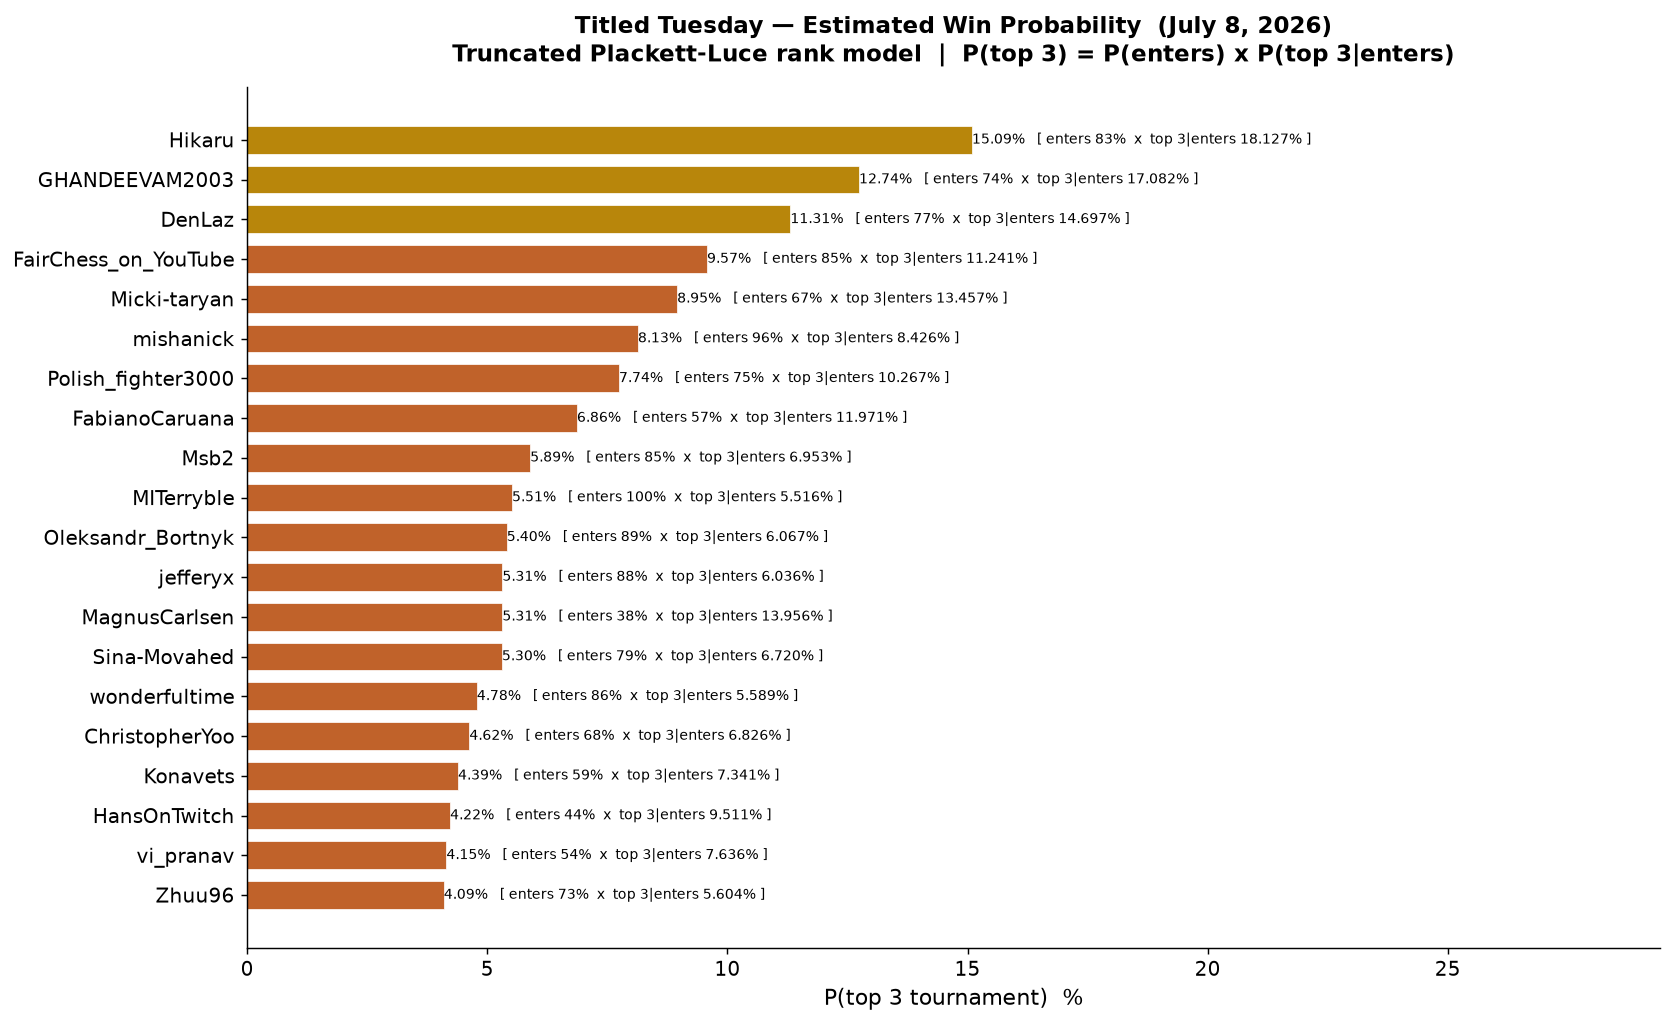

In [110]:
# ── Figure 1: Win probability ranking (top 20) ───────────────────────────
top20 = topn_probs.nlargest(20, 'P_top3').iloc[::-1].copy()

def bar_color(wins):
    if wins >= 10: return '#7b5800'
    if wins >= 5:  return '#b8860b'
    if wins >= 2:  return '#c0622a'
    if wins >= 1:  return '#4375a8'
    return '#708090'

colors = [bar_color(int(w)) for w in top20['P_top3']*50]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(
    top20.index, top20['P_top3'] * 100,
    color=colors, edgecolor='white', linewidth=0.4, height=0.7,
)

for bar, (_, row) in zip(bars, top20.iterrows()):
    note = (
        f"{row['P_top3']*100:.2f}%   "
        f"[ enters {row['p_participate']*100:.0f}%  x  "
        f"top 3|enters {row['P_top3_given_play']*100:.3f}% ]  "
    )
    ax.text(bar.get_width() + 0.004,
            bar.get_y() + bar.get_height() / 2,
            note, va='center', fontsize=7.8)

ax.set_xlim(0, top20['P_top3'].max() * 100 * 1.95)
ax.set_xlabel('P(top 3 tournament)  %', fontsize=12)
ax.set_title(
    'Titled Tuesday — Estimated Win Probability  (July 8, 2026)\n'
    'Truncated Plackett-Luce rank model  |  P(top 3) = P(enters) x P(top 3|enters)',
    fontsize=13, fontweight='bold', pad=14,
)
plt.tight_layout()
plt.savefig('top3_probability.png', dpi=150, bbox_inches='tight')
plt.show()

## 5  Win probability

$$P(i\text{ wins}) = p_i \cdot \frac{w_i}{\Sigma}, \qquad \Sigma = \sum_j p_j w_j$$

$P(i\text{ wins}\mid\text{enters}) = w_i / \Sigma$ — how often player $i$ wins relative to their competition, given they show up.

In [122]:
player_stats = context.reset_index().rename(columns={'index': 'username'})
player_stats['win_rate'] = player_stats['tourn_win'] / player_stats['appearances']

sigma = (player_stats['p_participate'] * player_stats['pl_strength']).sum()
player_stats['win_prob_cond'] = player_stats['pl_strength'] / sigma
player_stats['win_prob']      = player_stats['p_participate'] * player_stats['win_prob_cond']

top30 = player_stats.nlargest(30, 'win_prob').copy()
top30['p_%']    = (top30['p_participate']  * 100).round(1)
top30['cond_%'] = (top30['win_prob_cond']  * 100).round(3)
top30['win_%']  = (top30['win_prob']        * 100).round(3)

print(f'Expected field  : {expected_size:.0f} players')
print(f'Sigma           : {sigma:.4f}')
print()
print('Top 30 by P(wins):')
print(
    top30[['username','appearances','tourn_win','latest_rating',
           'p_%','pl_strength','cond_%','win_%']]
    .rename(columns={'p_%':'P(enters)%','pl_strength':'PL strength',
                     'cond_%':'P(win|enters)%','win_%':'P(win)%'})
    .to_string(index=False)
)

Expected field  : 432 players
Sigma           : 103.0838

Top 30 by P(wins):
            username  appearances  tourn_win latest_rating  P(enters)%  PL strength  P(win|enters)%  P(win)%
              Hikaru          317         77          3259        83.4     7.662197           7.433    6.196
      GHANDEEVAM2003          138          3          2990        74.4     7.475214           7.252    5.395
           mishanick          337         17          3034        96.4     5.050189           4.899    4.724
              DenLaz          204         13          3086        76.8     6.222948           6.037    4.635
  Polish_fighter3000          188         14          3116        75.0     5.806450           5.633    4.224
        Micki-taryan           28          1          2973        66.6     6.338982           6.149    4.094
       MagnusCarlsen          173         45          3209        37.8     9.929478           9.632    3.642
      FabianoCaruana          160          3       

## 6  Visualisations

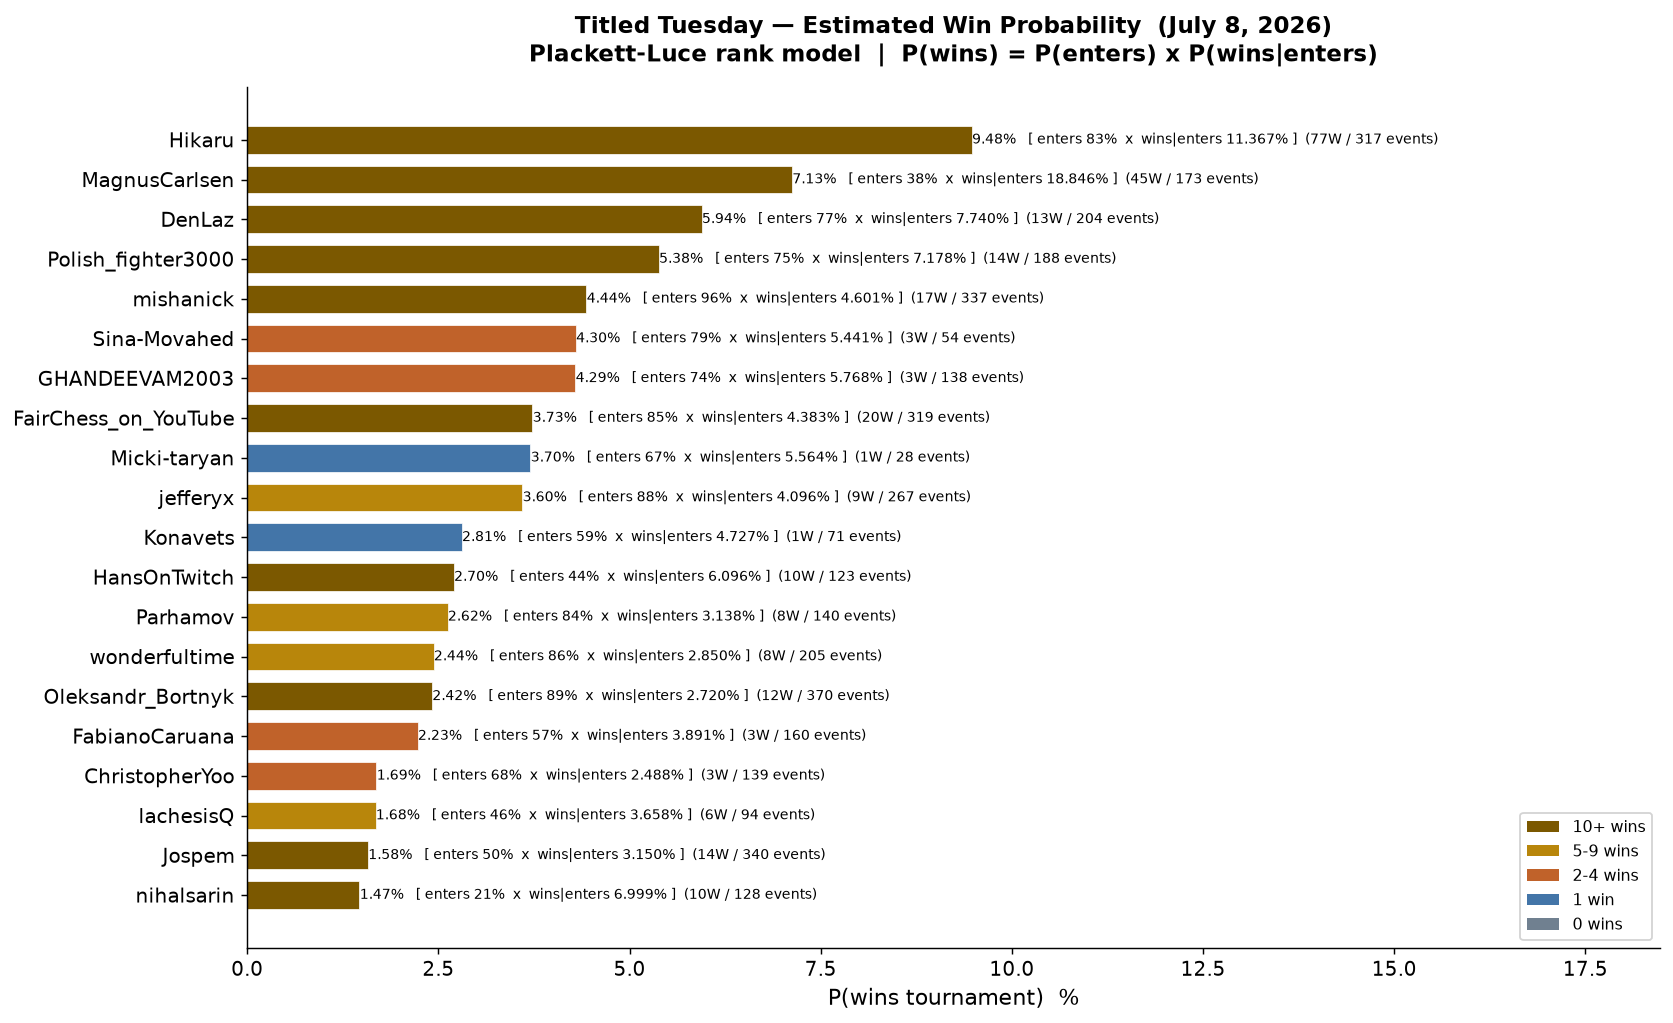

In [50]:
# ── Figure 1: Win probability ranking (top 20) ───────────────────────────
top20 = player_stats.nlargest(20, 'win_prob').iloc[::-1].copy()

def bar_color(wins):
    if wins >= 10: return '#7b5800'
    if wins >= 5:  return '#b8860b'
    if wins >= 2:  return '#c0622a'
    if wins >= 1:  return '#4375a8'
    return '#708090'

colors = [bar_color(int(w)) for w in top20['tourn_wins']]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(
    top20['username'], top20['win_prob'] * 100,
    color=colors, edgecolor='white', linewidth=0.4, height=0.7,
)

for bar, (_, row) in zip(bars, top20.iterrows()):
    note = (
        f"{row['win_prob']*100:.2f}%   "
        f"[ enters {row['p_participate']*100:.0f}%  x  "
        f"wins|enters {row['win_prob_cond']*100:.3f}% ]  "
        f"({int(row['tourn_wins'])}W / {int(row['appearances'])} events)"
    )
    ax.text(bar.get_width() + 0.004,
            bar.get_y() + bar.get_height() / 2,
            note, va='center', fontsize=7.8)

ax.set_xlim(0, top20['win_prob'].max() * 100 * 1.95)
ax.set_xlabel('P(wins tournament)  %', fontsize=12)
ax.set_title(
    'Titled Tuesday — Estimated Win Probability  (July 8, 2026)\n'
    'Plackett-Luce rank model  |  P(wins) = P(enters) x P(wins|enters)',
    fontsize=13, fontweight='bold', pad=14,
)
legend_els = [
    mpatches.Patch(facecolor='#7b5800', label='10+ wins'),
    mpatches.Patch(facecolor='#b8860b', label='5-9 wins'),
    mpatches.Patch(facecolor='#c0622a', label='2-4 wins'),
    mpatches.Patch(facecolor='#4375a8', label='1 win'),
    mpatches.Patch(facecolor='#708090', label='0 wins'),
]
ax.legend(handles=legend_els, loc='lower right', framealpha=0.85, fontsize=9)
plt.tight_layout()
plt.savefig('win_probability.png', dpi=150, bbox_inches='tight')
plt.show()

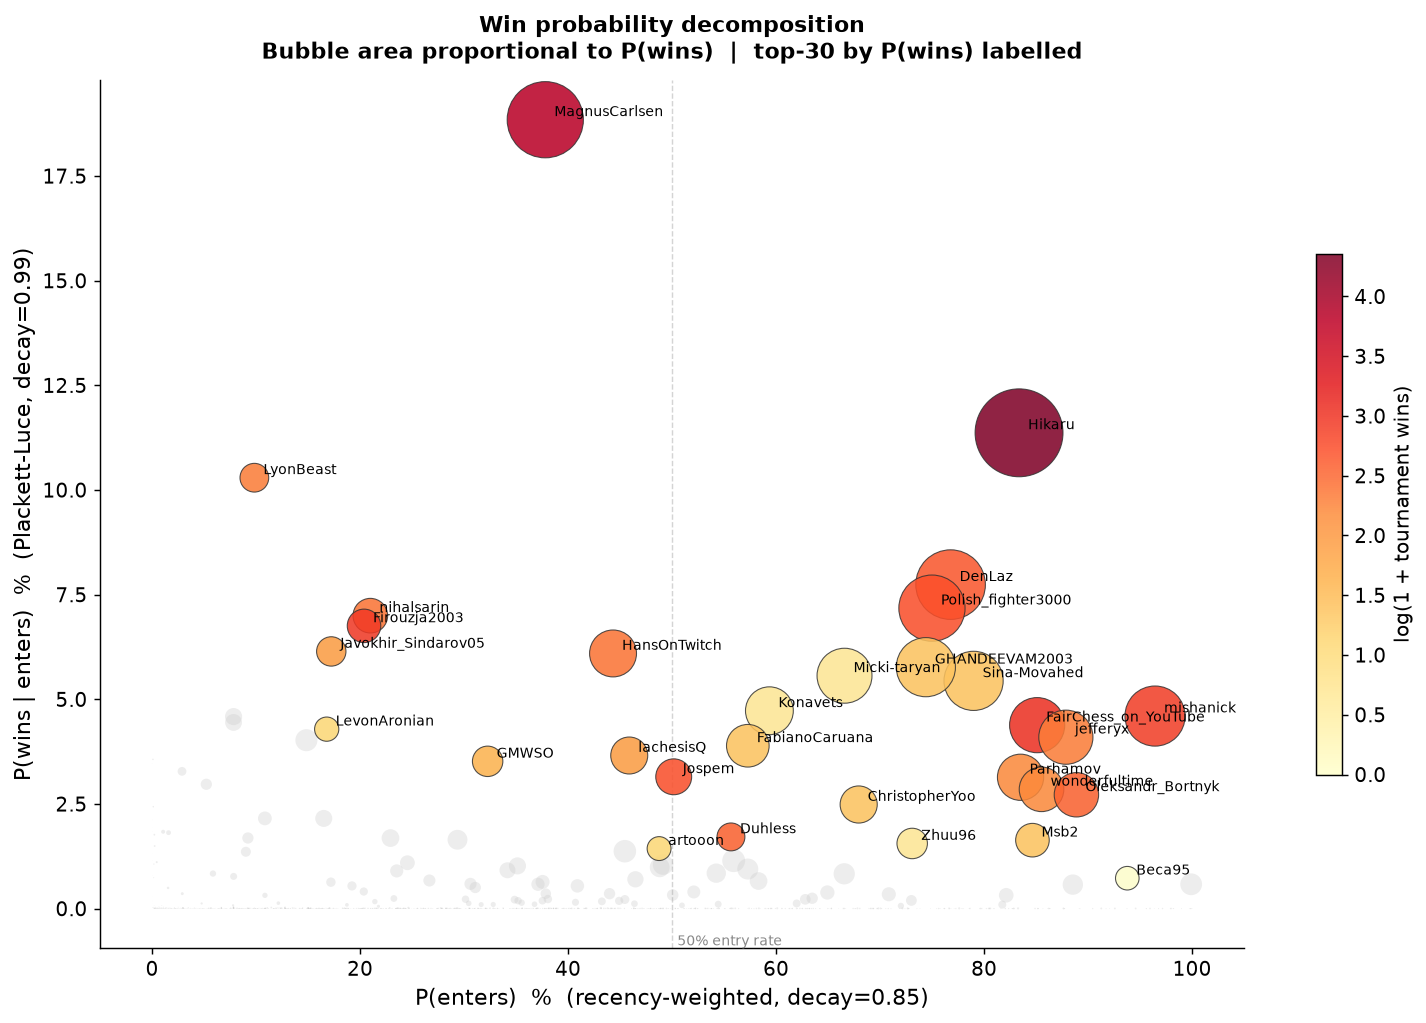

In [51]:
# ── Figure 2: Decomposition scatter ─────────────────────────────────────
scatter_df = player_stats[player_stats['appearances'] >= 5].copy()
LABEL_N    = 30
top_idx    = scatter_df.nlargest(LABEL_N, 'win_prob').index

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(
    scatter_df['p_participate'] * 100,
    scatter_df['win_prob_cond'] * 100,
    s=scatter_df['win_prob'] * 25000,
    c='#cccccc', alpha=0.35, edgecolors='none', zorder=2,
)
top_s = scatter_df.loc[top_idx]
sc = ax.scatter(
    top_s['p_participate'] * 100,
    top_s['win_prob_cond'] * 100,
    s=top_s['win_prob'] * 25000,
    c=np.log1p(top_s['tourn_wins']), cmap='YlOrRd',
    alpha=0.85, edgecolors='#333333', linewidths=0.6, zorder=3,
)
plt.colorbar(sc, ax=ax, shrink=0.6, label='log(1 + tournament wins)')

for _, row in top_s.iterrows():
    ax.annotate(row['username'],
                xy=(row['p_participate']*100, row['win_prob_cond']*100),
                xytext=(5, 2), textcoords='offset points',
                fontsize=7.5, zorder=4)

ax.set_xlabel('P(enters)  %  (recency-weighted, decay=0.85)', fontsize=12)
ax.set_ylabel('P(wins | enters)  %  (Plackett-Luce, decay=0.99)', fontsize=12)
ax.set_title(
    'Win probability decomposition\n'
    'Bubble area proportional to P(wins)  |  top-30 by P(wins) labelled',
    fontsize=12, fontweight='bold', pad=12,
)
ax.axvline(50, color='#aaaaaa', lw=0.8, ls='--', alpha=0.5)
ax.text(50.5, ax.get_ylim()[0]*1.02, '50% entry rate',
        fontsize=8, color='#888888', va='bottom')
plt.tight_layout()
plt.savefig('decomposition_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

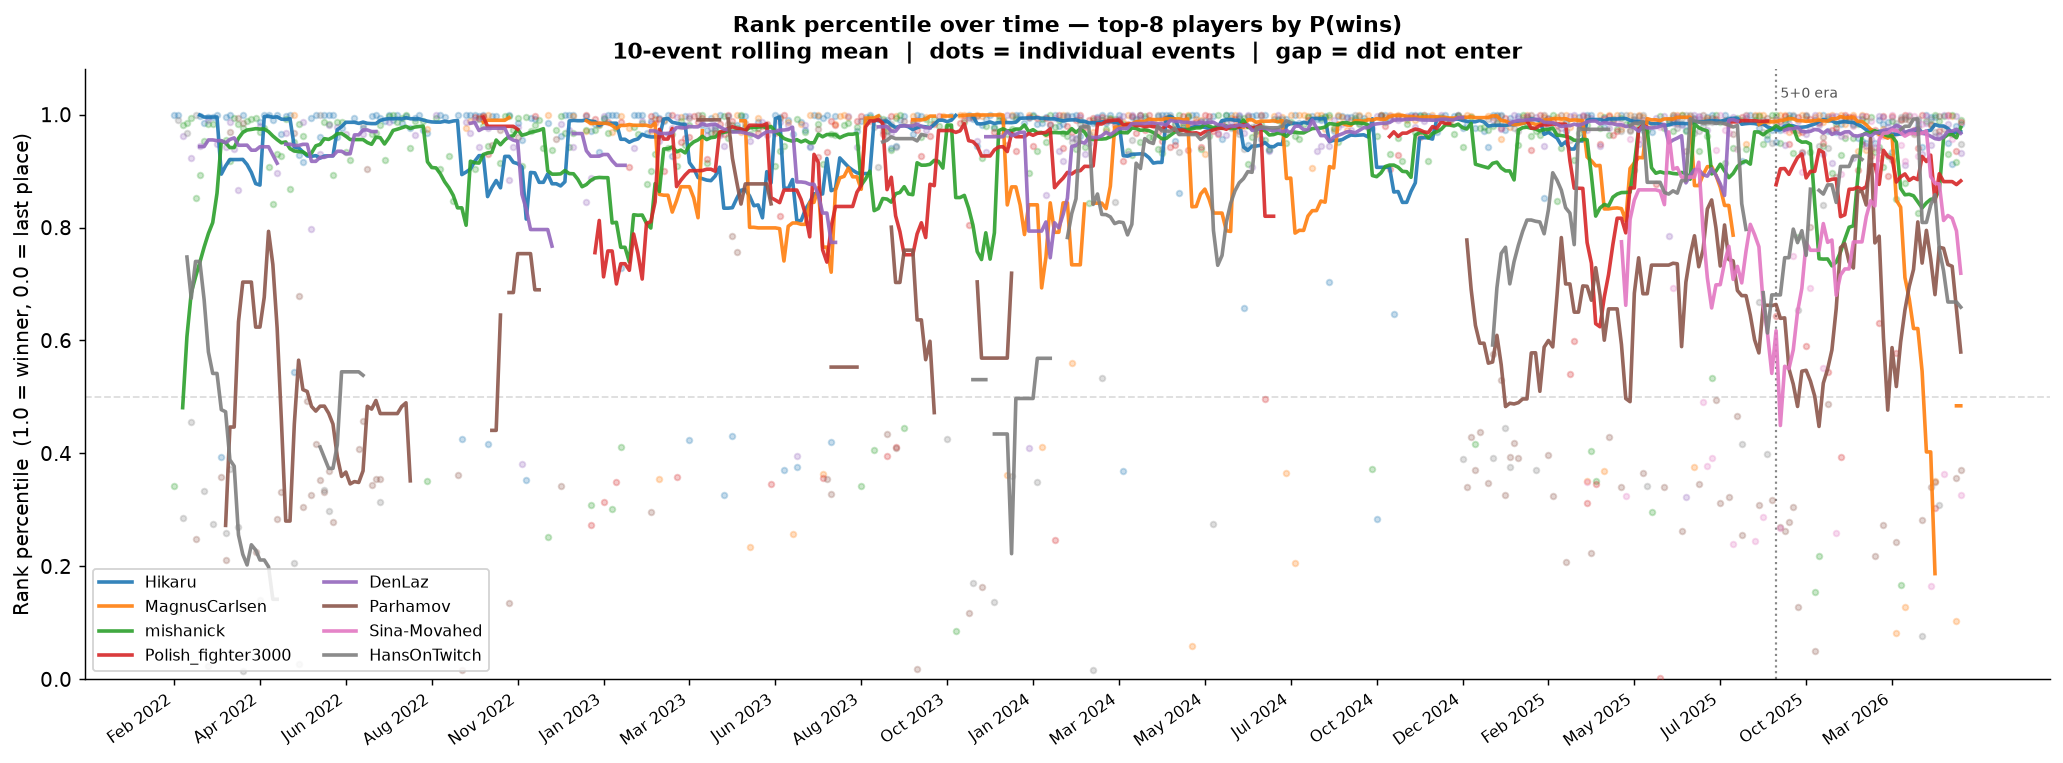

In [38]:
# ── Figure 3: Rank percentile timeline for top-8 ────────────────────────
# Each dot = one event's rank percentile (1.0=winner, 0.0=last).
# Line = 10-event rolling mean — shows genuine long-run form.
# This is the raw signal the Plackett-Luce model is fitted to.

top8_names = player_stats.nlargest(8, 'win_prob')['username'].tolist()
palette    = plt.cm.tab10.colors

df_pivot = (
    df.groupby(['username', 'tournament_slug'])['rank_pct']
    .first()
    .unstack('tournament_slug')
    .reindex(columns=slug_order)
)

fig, ax = plt.subplots(figsize=(16, 6))

for player, color in zip(top8_names, palette):
    pdata = (
        df_pivot.loc[player]
        if player in df_pivot.index
        else pd.Series(np.nan, index=slug_order)
    )
    smoothed = pdata.rolling(10, min_periods=3).mean()

    ax.scatter(range(N), pdata.values,
               color=color, s=10, alpha=0.25, zorder=3)
    ax.plot(range(N), smoothed.values,
            color=color, linewidth=2.0, label=player, alpha=0.90, zorder=4)

tick_step = 20
tick_pos  = list(range(0, N, tick_step))
ax.set_xticks(tick_pos)
ax.set_xticklabels(
    [tick_dates[i].strftime('%b %Y') for i in tick_pos],
    rotation=35, ha='right', fontsize=9,
)

era_idx = next(
    (i for i, d in enumerate(tick_dates) if d.date().isoformat() >= '2025-09-02'), N
)
ax.axvline(era_idx, color='#555555', lw=1.2, ls=':', alpha=0.7)
ax.text(era_idx + 1, 1.03, '5+0 era', fontsize=8, color='#555555')

ax.axhline(0.5, color='#bbbbbb', ls='--', lw=1, alpha=0.5)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Rank percentile  (1.0 = winner, 0.0 = last place)', fontsize=11)
ax.set_title(
    'Rank percentile over time — top-8 players by P(wins)\n'
    '10-event rolling mean  |  dots = individual events  |  gap = did not enter',
    fontsize=12, fontweight='bold',
)
ax.legend(loc='lower left', fontsize=9, ncol=2, framealpha=0.85)
plt.tight_layout()
plt.savefig('rank_percentile_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7  Model notes & caveats

**Why Plackett-Luce over normalized score?**
Normalized score (score/max) is a linear aggregate of average performance.
Winning a tournament is an extreme-value event — you must beat *every* other
player. Plackett-Luce directly models rank orderings, so a player who
consistently finishes 2nd–3rd accumulates a high strength estimate even with
zero wins, and their implied P(win) is appropriately much higher than a player
who finishes median. The model is internally calibrated: P(win) is proportional
to strength, and strength is determined by beating other players, not by a
score that depends on round count.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Data start | Feb 1, 2022 | Start of twice-weekly era; ~417 events |
| Tournament unit | `tournament_slug` | Early + late are separate events |
| `SKILL_DECAY` | 0.99 / event | Mild; ~100 events ago ≈ 37% weight |
| `PARTICIPATION_DECAY` | 0.85 / event | >20 events ago contributes <4% |
| `SIZE_DECAY` | 0.85 / event | Same reasoning |
| MM iterations | up to 300 | Convergence typically <100 iterations |

**Known limitations:**
- No forward-looking information (absences, schedule conflicts).
- Players with very few appearances have high-variance strength estimates.
- Swiss pairing creates mild dependencies between player scores that
  Plackett-Luce ignores (it assumes independent performance draws).
- Ratings shown are Chess.com blitz ratings at event time, not FIDE classical.